In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
import pandas as pd
import matplotlib.ticker as ticker
import re

In [2]:
def pass_at_k(n, c, k):
    """
    Calculate the pass@k metric.

    Args:
        n (int): Total number of samples.
        c (int): Number of correct samples.
        k (int): The k value in pass@k.

    Returns:
        float: The pass@k value, representing the probability of having at least one correct sample
               in k attempts.
    """
    # If the number of incorrect samples is less than k, return 1.0 (100% success rate)
    if n - c < k:
        return 1.0
    # Calculate the probability of failure for all k attempts and subtract from 1
    return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))

In [3]:
pass_at_k(50, 5, 2)

0.19183673469387752

In [4]:
workspace_base_path = lambda item: os.path.join('/checkpoint/maui/zhaobc/scientist/workspace', item)


In [5]:
ori_results = find_levels_in_configs_glob(
    [
        '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250422_*',
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250412_*',
        #  '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250408_*',
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250409_*',
    ]
)

Found 96 directories


In [6]:
from parse_levels import filter_folder_info

In [7]:
folder_info = ori_results

In [8]:
folder_info

{'record_10_20250422_111808_2071419-2071419-9': {'record': 10,
  'levels': [125],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'aide',
  'model': 'deepseek-r1',
  'n_initial_hypotheses': 3,
  'n_hypotheses': 3,
  'debug_prob': 0.5},
 'record_9_20250422_112110_2071459-2071450-8': {'record': 9,
  'levels': [125],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'bon',
  'model': 'deepseek-r1',
  'n_initial_hypotheses': None,
  'n_hypotheses': 3,
  'debug_prob': None},
 'record_18_20250422_112621_2071574-2071574-7': {'record': 18,
  'levels': [125],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'aide',
  'model': 'o3-mini',
  'n_initial_hypotheses': 3,
  'n_hypotheses': 3,
  'debug_prob': 0.5},
 'record_1_20250422_112110_2071451-2071450-0': {'record': 1,
  'levels': [125],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'bon',
  'model': 'deepseek-r1',
  'n_initial_hypotheses': None,
  'n_hypotheses': 3,
  'debug_prob': None},
 '

In [9]:
r1_bon = filter_folder_info(folder_info, [
   ('levels', 125),  # level 125 stands for using pseudo-code (1), text (2), and paper (5)
   ('runner', 'bon'),
   ('model', 'deepseek-r1'),
])
o3_bon = filter_folder_info(folder_info, [
   ('levels', 125), 
   ('runner', 'bon'),
   ('model', 'o3-mini'),
])
r1_aide = filter_folder_info(folder_info, [
   ('levels', 125), 
   ('runner', 'aide'),
   ('model', 'deepseek-r1'),
])
o3_aide = filter_folder_info(folder_info, [
   ('levels', 125), 
   ('runner', 'aide'),
   ('model', 'o3-mini'),
])

In [10]:
print(f"r1_bon: {len(r1_bon)}")
print(f"o3_bon: {len(o3_bon)}")
print(f"r1_aide: {len(r1_aide)}")
print(f"o3_aide: {len(o3_aide)}")

r1_bon: 18
o3_bon: 18
r1_aide: 34
o3_aide: 26


In [11]:
def process_metrics(record):
    for k, v in record.items():
        metrics = gather_metrics(
            workspace_base_path(k),
            metrics=['val_loss', 'train_time'],
            workspace_template_path=os.path.join(
                'workspace_templates', 
                'nanogpt_speedrun', 
                f"record_{v['record']}"
            )
        )
        metrics.loc[metrics['val_loss'] >= 3.29, 'train_time'] = np.nan
        record[k]['metrics'] = metrics
    return record


In [12]:
r1_bon_search = process_metrics(r1_bon)
o3_bon_search = process_metrics(o3_bon)
r1_aide_search = process_metrics(r1_aide)
o3_aide_search = process_metrics(o3_aide)

In [13]:
r1_bon_search

{'record_9_20250422_112110_2071459-2071450-8': {'record': 9,
  'levels': [125],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'bon',
  'model': 'deepseek-r1',
  'n_initial_hypotheses': None,
  'n_hypotheses': 3,
  'debug_prob': None,
  'metrics':     step  val_loss  train_time
  0      0    3.2785    505531.0
  1      1       NaN         NaN
  2      2    3.2784    559474.0
  3      3    3.2816    558221.0
  4      4    3.2771    566664.0
  5      5    3.2755    573196.0
  6      6    3.2746    565960.0
  7      7    3.2761    566850.0
  8      8    3.2761    567261.0
  9      9   10.8258         NaN
  10    10   10.8258         NaN
  11    11    3.2784    571145.0
  12    12   10.8258         NaN
  13    13    3.2771    519084.0
  14    14    3.2792    512326.0
  15    15    3.2798    513640.0
  16    16    3.2750    510573.0
  17    17    3.2786    516203.0
  18    18    3.2786    510136.0
  19    19    3.2819    513656.0
  20    20    3.2814    516377.0
  21    21   

In [14]:
def convert_to_dict(record):
    results = {}
    for k, v in record.items():
        # record_num = int(k.split('-')[-1])
        ## the +1 here is because the process is 0-indexed but record number is 1-indexed
        # results[record_num + 1] = v['metrics']['train_time'].min()
        # record_num = k.split('_2025')[0].split('_')[-1]
        pattern = r"^record_(\d+)_"
        match = re.match(pattern, k)
        record_num = int(match.group(1))
        if record_num in results:
            results[record_num] = min(results[record_num], v['metrics']['train_time'].min())
        else:
            results[record_num] = v['metrics']['train_time'].min()
        # results[record_num] = v['metrics']['train_time'].tolist()
    return results

# r1_flat_search_result = convert_to_dict(r1_flat_search)
# o3_flat_search_result = convert_to_dict(o3_flat_search)
r1_bon_search_result = convert_to_dict(r1_bon_search)
o3_bon_search_result = convert_to_dict(o3_bon_search)
r1_aide_search_result = convert_to_dict(r1_aide_search)
o3_aide_search_result = convert_to_dict(o3_aide_search)
# r1_bon_results = convert_to_dict(r1_bon_dummy_no_knowledge_l1)
# r1_aide_results = convert_to_dict(r1_aide_dummy_no_knowledge_l1)
# r1_aide_l12_results = convert_to_dict(r1_aide_dummy_no_knowledge_l12)
# # o3_bon_results = convert_to_dict(o3_bon_dummy_no_knowledge_l1)
# o3_aide_results = convert_to_dict(o3_aide_dummy_no_knowledge_l1)
# o3_aide_l12_results = convert_to_dict(o3_aide_dummy_no_knowledge_l12)

In [15]:

human_train_time_dict = {
    1: 2936369,
    2: 2304681,
    3: 1386147,
    4: 1301740,
    5: 949528,
    6: 766259,
    7: 773072,
    8: 662205,
    9: 505531,
    10: 477150,
    11: 442985,
    12: 317839,
    13: 289805,
    14: 273107,
    15: 241463,
    16: 232971,
    17: 220374,
    18: 211840,
    19: 199442
}

In [16]:
def compute_gap_in_percentage(
        model_time, 
        human_time=human_train_time_dict, 
    ):
    gaps = {}
    for k, v in human_time.items():
        if (k + 1) not in human_time:
            continue
        gaps[k] = v - human_time[k+1]
    
    recovered_times = {}
    for k, v in model_time.items():
        recovered_time = human_time[k] - v
        recovered_times[k] = recovered_time

    recovered_gap_in_percentage = {}
    for k, v in recovered_times.items():
        if (k + 1) not in gaps:
            continue
        recovered_gap_in_percentage[k] = v / gaps[k] if gaps[k] > 0 else 0

    return recovered_gap_in_percentage



In [17]:
# r1_bon_gap_in_percentage = compute_gap_in_percentage(r1_bon_results)
# r1_aide_gap_in_percentage = compute_gap_in_percentage(r1_aide_results)
# r1_aide_l12_gap_in_percentage = compute_gap_in_percentage(r1_aide_l12_results)
# # o3_bon_gap_in_percentage = compute_gap_in_percentage(o3_bon_results)
# o3_aide_gap_in_percentage = compute_gap_in_percentage(o3_aide_results)
# o3_aide_l12_gap_in_percentage = compute_gap_in_percentage(o3_aide_l12_results)
r1_bon_gap_in_percentage = compute_gap_in_percentage(r1_bon_search_result)
r1_aide_gap_in_percentage = compute_gap_in_percentage(r1_aide_search_result)
o3_bon_gap_in_percentage = compute_gap_in_percentage(o3_bon_search_result)
o3_aide_gap_in_percentage = compute_gap_in_percentage(o3_aide_search_result)


In [19]:
# delete the 6th record cause its upgrade pytorch which the agent cannot handle
del r1_bon_gap_in_percentage[6]
del r1_aide_gap_in_percentage[6]
del o3_bon_gap_in_percentage[6]
del o3_aide_gap_in_percentage[6]

In [21]:
r1_bon_gap_in_percentage = {str(k): v for k, v in r1_bon_gap_in_percentage.items()}
r1_aide_gap_in_percentage = {str(k): v for k, v in r1_aide_gap_in_percentage.items()}
o3_bon_gap_in_percentage = {str(k): v for k, v in o3_bon_gap_in_percentage.items()}
o3_aide_gap_in_percentage = {str(k): v for k, v in o3_aide_gap_in_percentage.items()}


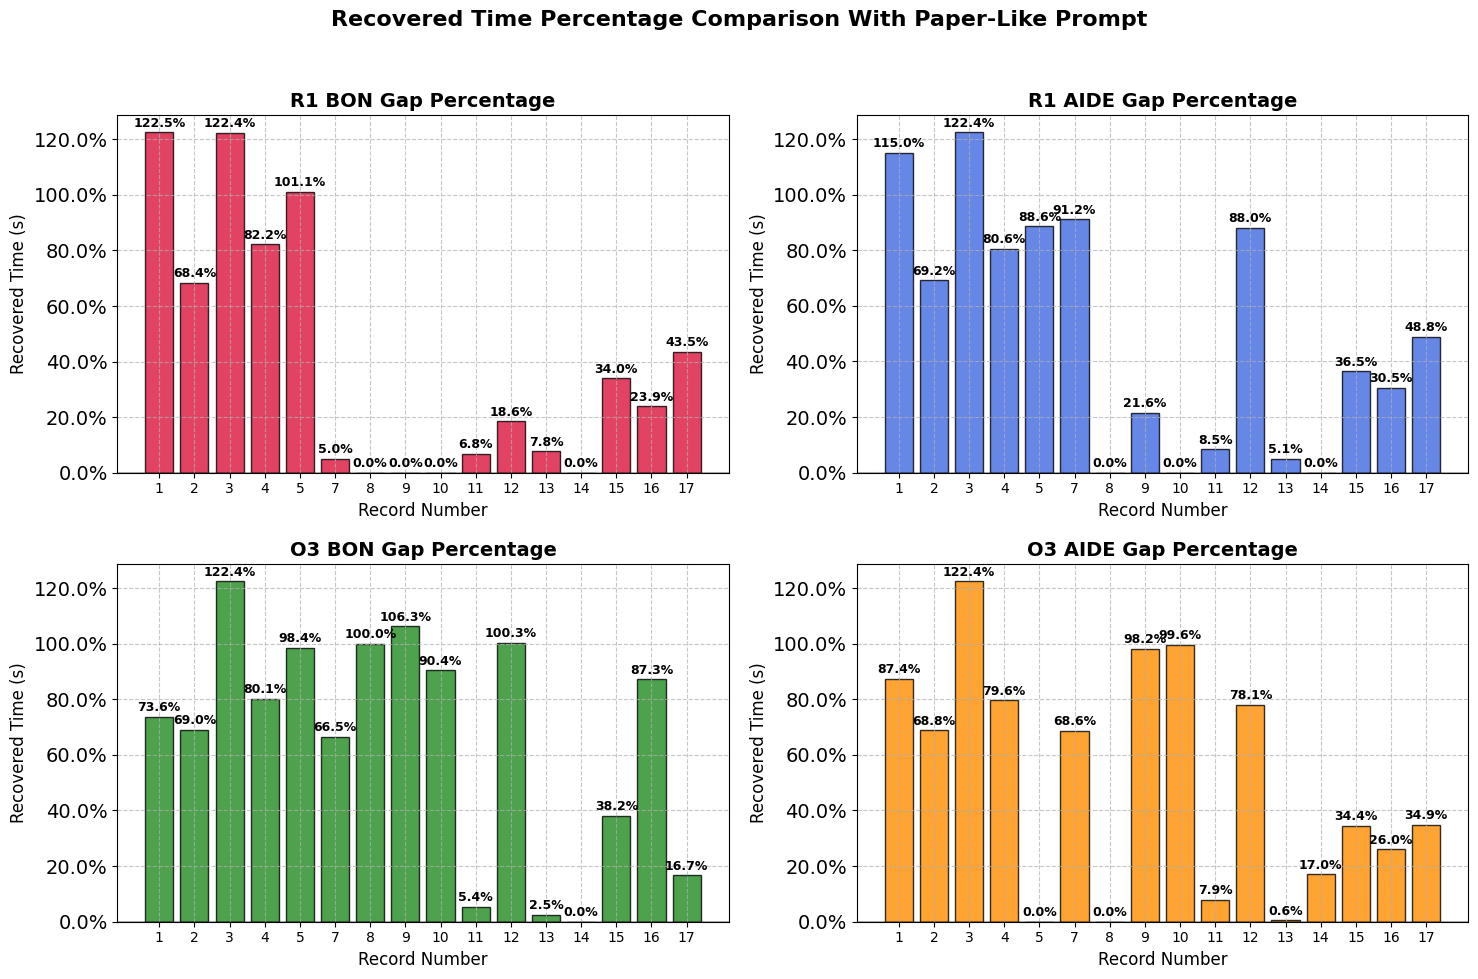

In [23]:

# Create a list of dictionaries and their titles with different colors
data_dicts = [
    (r1_bon_gap_in_percentage, "R1 BON Gap Percentage", 'crimson'),
    (r1_aide_gap_in_percentage, "R1 AIDE Gap Percentage", 'royalblue'),
    (o3_bon_gap_in_percentage, "O3 BON Gap Percentage", 'forestgreen'),
    (o3_aide_gap_in_percentage, "O3 AIDE Gap Percentage", 'darkorange')
]

# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()  # Flatten the 2x2 array to make indexing easier

# Create a barplot for each dictionary
for i, (data_dict, title, color) in enumerate(data_dicts):
    # Sort the dictionary by keys
    sorted_items = sorted(data_dict.items(), key=lambda x: int(x[0]))
    keys = [item[0] for item in sorted_items]
    values = [item[1] for item in sorted_items]
    
    # Create the barplot with the specified color
    bars = axs[i].bar(range(len(keys)), values, color=color, edgecolor='black', alpha=0.8)
    
    # Add title and labels
    axs[i].set_title(title, fontsize=14, fontweight='bold')
    axs[i].set_xlabel('Record Number', fontsize=12)
    axs[i].set_ylabel('Recovered Time (s)', fontsize=12)
    
    # Ensure all xticks are shown
    axs[i].set_xticks(range(len(keys)))
    axs[i].set_xticklabels(keys, fontsize=10)
    
    # Add grid for better readability
    axs[i].grid(True, linestyle='--', alpha=0.7)
    
    # Add a horizontal line at y=0
    axs[i].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Format y-axis as percentage
    axs[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    
    # Annotate the values on top of the bars
    for bar in bars:
        height = bar.get_height()
        if height >= 0:
            y_pos = height + 0.02
        else:
            y_pos = height - 0.05
        axs[i].text(
            bar.get_x() + bar.get_width()/2.,
            y_pos,
            '{:.1%}'.format(height),
            ha='center', 
            fontsize=9,
            fontweight='bold',
            color='black'
        )

# Add a main title for the figure
fig.suptitle('Recovered Time Percentage Comparison With Paper-Like Prompt', fontsize=16, fontweight='bold', y=0.98)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for the suptitle

# Show the plot
plt.show()